<a href="https://colab.research.google.com/github/Matheus0820/Aprendizado-de-Maquina/blob/main/unidade01/codes/Deep_MLP_para_prever_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Usando Deep MLP para prever o cancer

Aprendizado de Máquina 26.1

**Aluno:** Matheus Ramos Ferreira da Silva.

In [67]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/Matheus0820/Aprendizado-de-Maquina/refs/heads/main/unidade01/datasets/Cancer_Data.csv"
df = pd.read_csv(url)
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Entrada e Saída de dados

### Entradas
- radius_mean
- texture_mean
- perimeter_mean
- area_mean
- smoothness_mean
- compactness_mean
- concavity_mean
- concave points_mean
- texture_worst
- perimeter_worst
- area_worst
- smoothness_worst
- compactness_worst
- concavity_worst
- concave points_worst
- symmetry_worst
- fractal_dimension_worst


### Saídas:
- diagnosis
  - M: Tumor maligno (Cancer) → 1
  - B: Tumor Benigno → 0

In [68]:
X = df.drop(["diagnosis", "Unnamed: 32", "id"], axis=1).values
numero_entradas = len(X[0])
print(f"Número de entradas: {numero_entradas}\n\n")

Número de entradas: 30




In [69]:
y = df["diagnosis"].values
y = list(map(lambda yi: 1 if yi == "M" else 0, y))
y = np.array(y)
y = y.reshape(len(y), 1)
y[:5]

array([[1],
       [1],
       [1],
       [1],
       [1]])

## Normalização dos dados

In [70]:
# Importando biblioteca
from sklearn.preprocessing import StandardScaler

# Criando o Objeto do metodo de normalização
scaler = StandardScaler()

# Aplicando a normalização nos dados de X
X = scaler.fit_transform(X)
X[:1]

array([[ 1.09706398, -2.07333501,  1.26993369,  0.9843749 ,  1.56846633,
         3.28351467,  2.65287398,  2.53247522,  2.21751501,  2.25574689,
         2.48973393, -0.56526506,  2.83303087,  2.48757756, -0.21400165,
         1.31686157,  0.72402616,  0.66081994,  1.14875667,  0.90708308,
         1.88668963, -1.35929347,  2.30360062,  2.00123749,  1.30768627,
         2.61666502,  2.10952635,  2.29607613,  2.75062224,  1.93701461]])

## Dividindo em dados de treinamento e de teste

In [71]:
from numpy.random.mtrand import f
# Importando bibliotecas
from sklearn.model_selection import train_test_split
import time

# Criando variavél para ser a semente do random_state
time_random = int(time.time())

# Fazendo a divisão dos dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=time_random)

# Mostrando o Tamanho
print(f"Tamanho do conjunto de treinamento:")
print(f"- X_train: {X_train.shape}")
print(f"- y_train: {y_train.shape}\n")
print(f"Tamanho do conjunto de teste: ")
print(f"- X_test: {X_test.shape}")
print(f"- y_test: {y_test.shape}")

Tamanho do conjunto de treinamento:
- X_train: (455, 30)
- y_train: (455, 1)

Tamanho do conjunto de teste: 
- X_test: (114, 30)
- y_test: (114, 1)


## Treinamento da Deep MLP

In [72]:
# Importando o Tensor Flow
import tensorflow as tf

# Criando o classificador
classificador = tf.keras.models.Sequential()

# Adicionando a camada de entrada e a primeira camada escondida
classificador.add(tf.keras.layers.Dense(units=16, activation="relu", input_dim=numero_entradas, kernel_initializer = 'uniform'))

# Adicionando a segunda camada escondida
classificador.add(tf.keras.layers.Dense(units=16, activation="relu", kernel_initializer = 'uniform'))

# Adicionando a camada de saida
classificador.add(tf.keras.layers.Dense(units=1, activation="sigmoid", kernel_initializer = 'uniform'))

# Montando a Rede
classificador.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Treinando a rede neural

In [73]:
# Treinando com os dados de treino
classificador.fit(X_train, y_train, batch_size=10, epochs=100)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8022 - loss: 0.6815
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9363 - loss: 0.5371
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9516 - loss: 0.2602
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9604 - loss: 0.1387
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9714 - loss: 0.1041
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9758 - loss: 0.0871
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9824 - loss: 0.0769
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9824 - loss: 0.0702
Epoch 9/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9824 - loss: 0.0659
Epoch 10/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9846 - loss: 0.0628
Epoch 11/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9824 - loss: 0.0602
Epoch 12/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

## Avaliando a rede treinada

In [74]:
# Valores de y dados pela rede atraves dos dados de teste
y_pred = classificador.predict(X_test)
print("y gerados pela rede através dos dados de teste:")
print(y_pred[0:5])

y_pred = (y_pred > 0.5)
print("\ny gerados pela rede através dos dados de teste (boolean):")
print(y_pred[0:5])

# Gerando a Matriz de confusão
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
y gerados pela rede através dos dados de teste:
[[1.0000000e+00]
 [2.8306628e-02]
 [3.7642872e-06]
 [1.9545541e-06]
 [4.4692356e-06]]

y gerados pela rede através dos dados de teste (boolean):
[[ True]
 [False]
 [False]
 [False]
 [False]]


In [75]:
# Mostrando a taxa de acerto e a matriz de confusão
print(f"Taxa de acerto: {accuracy_score(y_test, y_pred)}")
print(f"Taxa de acerto em %: {(accuracy_score(y_test, y_pred))*100:.2f}%")
print("\nMatriz de confusão:")
print(cm)

Taxa de acerto: 0.9736842105263158
Taxa de acerto em %: 97.37%

Matriz de confusão:
[[67  1]
 [ 2 44]]


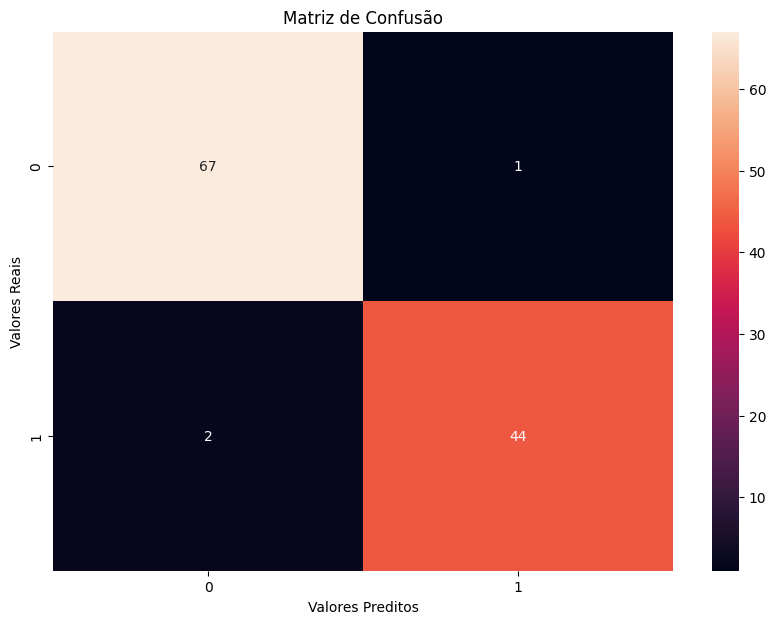

In [76]:
# Versão gráfica da matriz de confusão
import seaborn as sn
import matplotlib.pyplot as plt

df_cm = pd.DataFrame(cm, index = [i for i in "01"], columns = [i for i in "01"])
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='g')
plt.title('Matriz de Confusão')
plt.xlabel('Valores Preditos')
plt.ylabel('Valores Reais')

# Plotando
plt.show()
